In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import zipfile
import os

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


In [5]:
import urllib.request
import zipfile

# Rutas
DATA_RAW_DIR = "../data/raw"
DATA_PROC_DIR = "../data/processed"
ZIP_PATH = os.path.join(DATA_RAW_DIR, "denue_09_csv.zip")
PROCESSED_CSV = os.path.join(DATA_PROC_DIR, "salud_cdmx_denue_limpio.csv")

# URL del zip (SAS token válido hasta el 9 de junio de 2026)
DENUE_ZIP_URL = (
    "https://cfcetlsadls.blob.core.windows.net/raw/inegi/denue_por_estado/"
    "ciudad_de_mexico_zip/denue_09_csv.zip"
    "?sv=2025-07-05&spr=https&st=2026-04-24T19%3A24%3A46Z"
    "&se=2026-06-09T19%3A24%3A00Z&sr=b&sp=r"
    "&sig=%2F5%2BqqFCki1Y%2Bdl3Y21slq3HOd7Ek5cDjh849JlR37Dc%3D"
)

os.makedirs(DATA_RAW_DIR, exist_ok=True)
os.makedirs(DATA_PROC_DIR, exist_ok=True)

# 1) Descargar el zip si no existe
if not os.path.exists(ZIP_PATH):
    print("Descargando DENUE CDMX (puede tomar 1-2 min)...")
    urllib.request.urlretrieve(DENUE_ZIP_URL, ZIP_PATH)
    print(f"  -> {ZIP_PATH} ({os.path.getsize(ZIP_PATH)/1e6:.1f} MB)")
else:
    print(f"OK: zip ya existe en {ZIP_PATH}")

# 2) Regenerar el CSV procesado si no existe (replica la lógica del notebook 01)
if not os.path.exists(PROCESSED_CSV):
    print("\nRegenerando CSV procesado desde el zip (lógica del notebook 01)...")
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        df_raw = pd.read_csv(
            z.open("conjunto_de_datos/denue_inegi_09_.csv"),
            encoding="latin1",
            low_memory=False,
        )

    df_tmp = df_raw[df_raw["codigo_act"].astype(str).str.startswith("62")].copy()
    df_tmp["latitud"] = pd.to_numeric(df_tmp["latitud"], errors="coerce")
    df_tmp["longitud"] = pd.to_numeric(df_tmp["longitud"], errors="coerce")
    df_tmp = df_tmp.dropna(subset=["latitud", "longitud"])

    cols = ["id", "nom_estab", "codigo_act", "nombre_act", "per_ocu",
            "municipio", "localidad", "latitud", "longitud", "fecha_alta"]
    df_tmp[cols].to_csv(PROCESSED_CSV, index=False)
    print(f"  -> {PROCESSED_CSV} ({len(df_tmp):,} filas)")
else:
    print(f"OK: CSV procesado ya existe en {PROCESSED_CSV}")

OK: zip ya existe en ../data/raw/denue_09_csv.zip
OK: CSV procesado ya existe en ../data/processed/salud_cdmx_denue_limpio.csv


In [6]:
# revisar contenidos del zip

zip_path = "../data/raw/denue_09_csv.zip"

with zipfile.ZipFile(zip_path, "r") as z:
    archivos = z.namelist()
    print(archivos)

['diccionario_de_datos/denue_diccionario_de_datos.csv', 'conjunto_de_datos/denue_inegi_09_.csv', 'metadatos/metadatos_denue.txt']


In [7]:
# cargar el csv dentro del zip a un DataFrame

with zipfile.ZipFile(zip_path, "r") as z:
    csv_name = "conjunto_de_datos/denue_inegi_09_.csv"
    df = pd.read_csv(z.open(csv_name), encoding="latin1")

df.head()

/var/folders/r6/00lc2hsn7p3d8b2ltf471xk00000gn/T/ipykernel_5251/3879774613.py:5: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(z.open(csv_name), encoding="latin1")


,id,clee,nom_estab,raz_social,codigo_act,nombre_act,per_ocu,tipo_vial,nom_vial,tipo_v_e_1,...,localidad,ageb,manzana,telefono,correoelec,www,tipoUniEco,latitud,longitud,fecha_alta
0,11845788,09013112515000091000000000U5,AJOLOTARIO APATLACO,NaN,112515,Piscicultura en agua dulce,0 a 5 personas,PRIVADA,Ninguno,PRIVADA,...,Apatlaco ...,1281,800,5.577368e+09,EDUARDOSANCHEVALDERRAMA@GMAIL.COM,NaN,Fijo,19.264524,-99.089505,2025-05
1,11845785,09013112515000071000000000U7,AJOLOTARIO CARRIZAL,NaN,112519,Otra acuicultura,0 a 5 personas,CERRADA,Ninguno,CERRADA,...,Paraje de la Ciénega,1281,800,5.526720e+09,NaN,NaN,Fijo,19.275685,-99.101824,2025-05
2,11845786,09013112515000082000000000U4,AJOLOTARIO CHINAMPA ONKALI,ONKALI SC DE RL,112519,Otra acuicultura,6 a 10 personas,OTRO(ESPECIFIQUE),Canal,CALLE,...,Xochimilco ...,1099,34,5.518275e+09,NaN,NaN,Fijo,19.277486,-99.097971,2025-05
3,11845789,09013112515000102000000000U0,AJOLOTARIO TLAZOCAMA TONANA,NaN,112519,Otra acuicultura,6 a 10 personas,OTRO(ESPECIFIQUE),Canal,CALLEJON,...,Xochimilco ...,1099,15,NaN,ORTADAVID294@GMAIL.COM,NaN,Fijo,19.274853,-99.101802,2025-05
4,11845781,09013112515000051000000000U9,AJOLOTERIA APANTLI,NaN,112519,Otra acuicultura,0 a 5 personas,PRIVADA,Ninguno,PRIVADA,...,Chililico ...,1281,800,5.561064e+09,JESUSC.AXOLOTL@GMAIL.COM,NaN,Fijo,19.265019,-99.090506,2025-05


In [8]:
# revisar columnas 

df.columns

Index(['id', 'clee', 'nom_estab', 'raz_social', 'codigo_act', 'nombre_act',
       'per_ocu', 'tipo_vial', 'nom_vial', 'tipo_v_e_1', 'nom_v_e_1',
       'tipo_v_e_2', 'nom_v_e_2', 'tipo_v_e_3', 'nom_v_e_3', 'numero_ext',
       'letra_ext', 'edificio', 'edificio_e', 'numero_int', 'letra_int',
       'tipo_asent', 'nomb_asent', 'tipoCenCom', 'nom_CenCom', 'num_local',
       'cod_postal', 'cve_ent', 'entidad', 'cve_mun', 'municipio', 'cve_loc',
       'localidad', 'ageb', 'manzana', 'telefono', 'correoelec', 'www',
       'tipoUniEco', 'latitud', 'longitud', 'fecha_alta'],
      dtype='object')

In [9]:
# ver cuántos establecimientos hay por cada código_act único
establecimientos_por_codigo = df["codigo_act"].value_counts()
print(establecimientos_por_codigo)

# ver cuántos código_act únicos hay
codigos_unicos = df["codigo_act"].nunique()
print("Número de códigos de actividad únicos:", codigos_unicos)

codigo_act
461110    38514
812110    23467
461130    13126
465311    12173
463211    11517
          ...  
324110        1
324120        1
335910        1
237313        1
521110        1
Name: count, Length: 925, dtype: int64
Número de códigos de actividad únicos: 925


In [10]:
# filtrar por sector salud

df_salud = df[df["codigo_act"].astype(str).str.startswith("62")].copy()

print("Total de establecimientos en CDMX:", len(df))
print("Establecimientos del sector salud:", len(df_salud))

df_salud.head()

Total de establecimientos en CDMX: 460761
Establecimientos del sector salud: 22841


,id,clee,nom_estab,raz_social,codigo_act,nombre_act,per_ocu,tipo_vial,nom_vial,tipo_v_e_1,...,localidad,ageb,manzana,telefono,correoelec,www,tipoUniEco,latitud,longitud,fecha_alta
304457,11822253,09015621411000053000061236S6,MARIE STOPES CONDESA,FUNDACION MARIE STOPES MEXICO AC,621411,Centros de planificación familiar del sector p...,11 a 30 personas,CALLE,Atlixco,AVENIDA,...,Cuauhtémoc ...,1182,2,5.560513e+09,MAYRA.CRUZ@MARIESTOPES.ORG.MX,WWW.MARIESTOPES.ORG.MX,Fijo,19.415518,-99.172861,2025-04
304458,6795800,09013621511000421000003549S7,113 LABORATORIO MEDICO DEL CHOPO SUCURSAL ARENAL,GRUPO DIAGNOSTICO MEDICO PROA SA DE CV,621511,Laboratorios médicos y de diagnóstico del sect...,0 a 5 personas,CALLE,PASEO DE LA VIRGEN,CALLE,...,Xochimilco ...,0014,15,NaN,INFORMES.WEB@CHOPO.COM.MX,WWW.CHOPO.COM.MX,Fijo,19.280340,-99.137950,2017-03
304459,8485187,09015624191001661000000000S0,19 DISTRITO DE SERVICIOS GENERALES ALCOHOLICOS...,DAMIAN INIESTRA ANTUNEZ AC,624191,Agrupaciones de autoayuda para alcohólicos y p...,0 a 5 personas,CALLE,LUDWING VAN BEETHOVEN,CALLE,...,Cuauhtémoc ...,0023,11,5.587393e+09,NaN,NaN,Fijo,19.460542,-99.131678,2019-11
304460,767683,09005624191000011001000000U0,1ER DISTRITO AREA NORTE DE ALCOHOLICOS ANONIMOS,ALCOHOLICOS ANONIMOS AC,624191,Agrupaciones de autoayuda para alcohólicos y p...,0 a 5 personas,CALLE,306,CALLE,...,Gustavo A. Madero ...,1186,15,NaN,NaN,NaN,Fijo,19.492214,-99.087259,2010-07
304461,11366041,09017621211005831000000000U0,20 DENTAL,NaN,621211,Consultorios dentales del sector privado,0 a 5 personas,CALLE,CERAMICA,CALLE,...,Venustiano Carranza ...,0282,25,NaN,NaN,NaN,Fijo,19.440626,-99.107722,2024-11


In [11]:
# revisar qué actividades quedaron dentro del sector salud
df_salud["nombre_act"].value_counts()

nombre_act
Consultorios dentales del sector privado                                                                                               7287
Consultorios de medicina especializada del sector privado                                                                              3160
Consultorios de medicina general del sector privado                                                                                    2793
Otros consultorios del sector privado para el cuidado de la salud                                                                      1379
Agrupaciones de autoayuda para alcohólicos y personas con otras adicciones                                                             1264
                                                                                                                                       ... 
Servicios de bancos de órganos, bancos de sangre y otros servicios auxiliares al tratamiento médico prestados por el sector privado       3
Servicios

In [12]:
# cuántas actividades distintas hay dentro del sector salud
df_salud["nombre_act"].nunique()

62

In [13]:
# limpiar coordenadas

df_salud["latitud"] = pd.to_numeric(df_salud["latitud"], errors="coerce")
df_salud["longitud"] = pd.to_numeric(df_salud["longitud"], errors="coerce")

df_salud = df_salud.dropna(subset=["latitud", "longitud"]).copy()

df_salud[["latitud", "longitud"]].describe()

,latitud,longitud
count,22841.000000,22841.000000
mean,19.379216,-99.137932
std,0.073124,0.064129
min,19.135360,-99.334098
25%,19.326660,-99.177286
50%,19.379934,-99.145724
75%,19.429417,-99.096517
max,19.579067,-98.951391


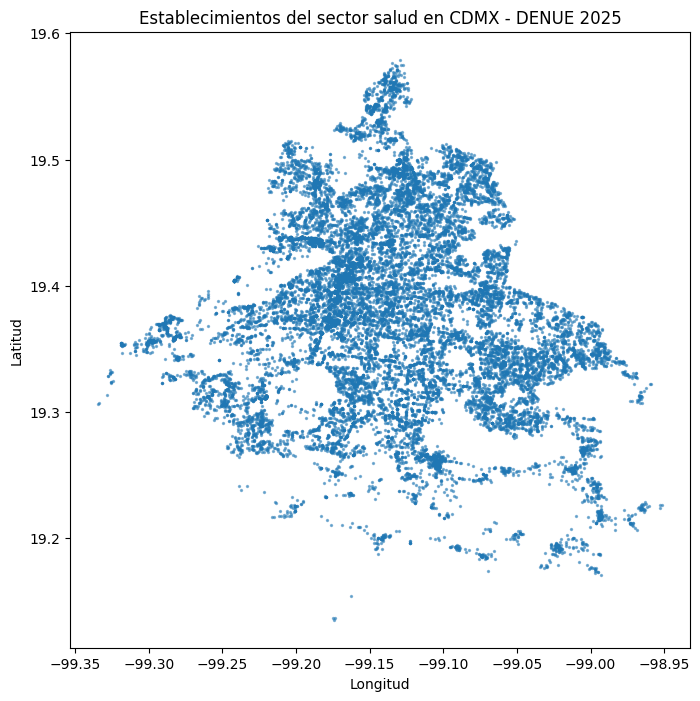

In [14]:
# hacer el primer gráfico de puntos

plt.figure(figsize=(8, 8))

plt.scatter(
    df_salud["longitud"],
    df_salud["latitud"],
    s=2,
    alpha=0.5
)

plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.title("Establecimientos del sector salud en CDMX - DENUE 2025")
plt.show()

In [15]:
# seleccionar columnas relevantes para el análisis

columnas_utiles = [
    "id",
    "nom_estab",
    "codigo_act",
    "nombre_act",
    "per_ocu",
    "municipio",
    "localidad",
    "latitud",
    "longitud",
    "fecha_alta"
]

df_salud_limpio = df_salud[columnas_utiles].copy()

df_salud_limpio.head()

,id,nom_estab,codigo_act,nombre_act,per_ocu,municipio,localidad,latitud,longitud,fecha_alta
304457,11822253,MARIE STOPES CONDESA,621411,Centros de planificación familiar del sector p...,11 a 30 personas,Cuauhtémoc,Cuauhtémoc ...,19.415518,-99.172861,2025-04
304458,6795800,113 LABORATORIO MEDICO DEL CHOPO SUCURSAL ARENAL,621511,Laboratorios médicos y de diagnóstico del sect...,0 a 5 personas,Xochimilco,Xochimilco ...,19.280340,-99.137950,2017-03
304459,8485187,19 DISTRITO DE SERVICIOS GENERALES ALCOHOLICOS...,624191,Agrupaciones de autoayuda para alcohólicos y p...,0 a 5 personas,Cuauhtémoc,Cuauhtémoc ...,19.460542,-99.131678,2019-11
304460,767683,1ER DISTRITO AREA NORTE DE ALCOHOLICOS ANONIMOS,624191,Agrupaciones de autoayuda para alcohólicos y p...,0 a 5 personas,Gustavo A. Madero,Gustavo A. Madero ...,19.492214,-99.087259,2010-07
304461,11366041,20 DENTAL,621211,Consultorios dentales del sector privado,0 a 5 personas,Venustiano Carranza,Venustiano Carranza ...,19.440626,-99.107722,2024-11


In [16]:
# guardar el DataFrame limpio a un nuevo archivo CSV

os.makedirs("../data/processed", exist_ok=True)

df_salud_limpio.to_csv(
    "../data/processed/salud_cdmx_denue_limpio.csv",
    index=False
)